# The Geometric and Algorithmic Foundations of Eigenvalues and Eigenvectors: A Deep Learning and Statistical Perspective

Linear algebra serves as the fundamental language and architectural framework for high-dimensional mathematics, statistics, quantum mechanics, and artificial intelligence. At the absolute core of this mathematical discipline is the concept of a linear transformation - a highly structured mapping between vector spaces that strictly preserves the operations of vector addition and scalar multiplication. When a matrix operates on a multi-dimensional vector space, it generally subjects the space to a combination of rotating, skewing, shearing, and scaling operations. Consequently, the vast majority of vectors subjected to a given linear transformation are knocked off their original span, changing their direction entirely as the space warps around the origin. However, the true geometric essence of any matrix is revealed not by the infinite number of vectors it displaces, but by the highly specific vectors it leaves completely invariant in direction. <br><br>
These special, invariant directions are known throughout mathematics as eigenvectors, and the specific scalar factor by which they are stretched, compressed, or flipped along their original span is defined as the corresponding eigenvalue. Understanding these mathematical entities is not merely an academic exercise in matrix factorisation or abstract algebra; it is the theoretical bedrock required required for diagnosing and predicting the behaviour of complex,high-dimensional systems. The spectral properties of matrices - the complete set of their eigenvalues and eigenvectors - dictate the flow of variance in statistical distributions, thereby enabling powerful dimensionality reduction techniques such as Principal Component Analysis (PCA). Furthermore, in the rapidly expanding realm of deep learning, the eigenvalues of weight matrices and sequential Jacobians strictly govern the stability of optimisation trajectories. These spectral mechanics fundamentally explain why neural network gradients catastrophically vanish or explode over deep architectural horizons, dictating the success or failure of model training. <br><br>
This comprehensive research report systematically unpacks the deep geometric and algebraic meaning of eigenvalues and eigenvectors. The analysis begins with the foundational definitions of linear algebra and the derivation of characteristic polynomials, advances through the profound implications of the Spectral Theorem for symmetric matrices, details rigorous manual and computational solver methodologies, visualises these invariant directions through programmed transformations, and finally bridges these foundational concepts to the empirical mechanics of PCA and the training dynamics of deep neural networks.

Eigenvalues:
 [3.61803399 1.38196601]

Eigenvectors (columns):
 [[ 0.85065081 -0.52573111]
 [ 0.52573111  0.85065081]]

Check for eigenvalue 3.618:
Av = [3.07768354 1.90211303]
λv = [3.07768354 1.90211303]

Check for eigenvalue 1.382:
Av = [-0.72654253  1.1755705 ]
λv = [-0.72654253  1.1755705 ]


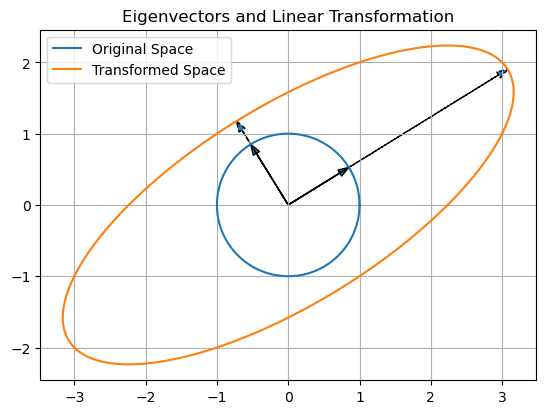

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Define a linear transformation
# ----------------------------
A = np.array([[3, 1],
              [1, 2]])

# ----------------------------
# 2. Compute eigenvalues/eigenvectors
# ----------------------------
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors (columns):\n", eigenvectors)

# ----------------------------
# 3. Verify Av = λv
# ----------------------------
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    print(f"\nCheck for eigenvalue {eigenvalues[i]:.3f}:")
    print("Av =", A @ v)
    print("λv =", eigenvalues[i] * v)

# ----------------------------
# 4. Visualization
# ----------------------------
fig, ax = plt.subplots()

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
circle = np.array([np.cos(theta), np.sin(theta)])
transformed_circle = A @ circle

ax.plot(circle[0], circle[1], label="Original Space")
ax.plot(transformed_circle[0], transformed_circle[1], label="Transformed Space")

# Plot eigenvectors
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    ax.arrow(0, 0, v[0], v[1],
             head_width=0.1, length_includes_head=True)
    ax.arrow(0, 0,
             eigenvalues[i]*v[0],
             eigenvalues[i]*v[1],
             linestyle='dashed',
             head_width=0.1,
             length_includes_head=True)

ax.set_aspect('equal')
ax.legend()
ax.set_title("Eigenvectors and Linear Transformation")
plt.grid()
plt.show()

## The Algebraic Formulation and the Characteristic Polynomial

### The Fundamental EigenValue Equation

In classical linear algebra, a square matrix $A \to \mathbb {R}^{n*n}$ acts on an input vector $x \to \mathbb {R}^n$ to produce a newly transformed output vector $Ax$. An eigenvector of the matrix $A$ is formally defined as a non-zero vector $x$ such that the output of the transformation $Ax$ is strictly parallel to the original input vector $x$. This proportional relationship is elegantly formalised by the fundamental eigenvalue equation : 
$$Ax = \lambda x$$
In this formulation, the term $\lambda$ represents a scalar known as the eigenvalue. The vector $x$ must be strictly non-zero because the trivial solution $A(0) = \lambda(0)$ mathematically holds true for all possible matrics and all possible scalars, offering precisely zero analytical or geometric value. To systematically solve for the unknown vectors and scalars that satisfy this condition, the equation must be algebraically rearranged . By introducing the identity matrix $ I$ - a matrix with ones on the main diagonal and zeros elsewhere, which acts as the multiplication identity in matrix algebra - the scalar multiplication on the right side of the equation can be written as matrix multiplication: 
$$Ax = (\lambda I)x$$
Subtracting the right side from the left yields a homogenous system of linear equations: 
$$Ax - \lambda Ix = 0$$$$(A - \lambda I)x = 0$$

### The Determinant and the Characteristic Polynomial 

For this newly formed homogeneous system to possess a non-trivial solution (where the vector x is not the zero vector), the transformed matrix ($A-\lambda I$) must be structurally singular. In linear algebra, a singular matrix is one whose columns are linearly dependent, meaning the matrix does not possess an inverse, and the transformation it represents fundamentally collapses the n-dimensional space into a lower-dimensional subspace (such as crushing a 3D volume into a 2D plane or a 1D line). <br><br>
The mathematical operation that precisely measures the scaling factor of an n-dimensional volume under a linear transformation is the determinant. If the volume collapses entirely to zero, the determinant of the trasformation must necessarily equal zero. This fundamental geometric constraint yields the characteristic equation of the matrix: 
$$ det(A- \lambda I) = 0 $$
Calculating the determinant of the matrix ($A- \lambda I$) algebraically expands into a polynomial of degree n in terms of the variable $\lambda$. This resultant expression is universally known as the characteristic polynomial. According to the Fundamental Theorem of Algebra, any polynomial of degree n possesses exactly n roots (when accounting for complex numbers and algebraic multiplicities). Each unique root of this characteristic polynomial represents a valid eigenvalue of the original matrix $A$. If any single eigenvalue is zero, the product of the eigenvalues is zero, meaning the determinant of $A$ is zero, which immediately proves that the matrix $A$ itself is singular and non-invertible.

## The Deep Geometric Meaning of Invariant Directions 

The algebraic equations governing governing spectral theory mask a profoundly elegant geometric reality. The geometric interpretation of eigenvectors centers entirely on the concept of invariant directional spans. A linear transformation can be visualised conceptually as morphing a perfectly uniform grid of space. During this spatial morhping, the vast majority of arbitrary vectors pointing outward from the origin will be rotated away from their original lines of span, simultaneously changing both their length and their angular orientation. <br><br>
However, eigenvectors define highly special, structurally critical lines passing directly through the origin that remain completely fixed in place during the transformation. When the matrix $A$ is applied to the space, any coordinate point lying anywhere on an eigenline stays strictly on that exact same line. The matrix operates on these specific geometric directions not by rotating, skewing, or shearing them, but purely through simple, one-dimensional scaling. The eigenvectors effectively act as the independent structural skeleton around which the rest of the geometric transformation bends and warps.<br><br>
The eigenvalue $\lambda$ associated with each eigen vector encodes the exact mathematical magnitude and directional polarity of this pure scaling action. The precise value of the eigenvalue dictates the resulting geometry : 
<table style="width:100%; border-collapse: collapse;">
  <tr>
    <th style="width:30%; text-align:left;">Eigenvalue Condition</th>
    <th style="width:70%; text-align:left;">Geometric Interpretation of the Transformation</th>
  </tr>
  <tr>
    <td>$\lambda > 1$</td>
    <td>Stretched outward along its span, moving further from the origin.</td>
  </tr>
  <tr>
    <td>$0 < \lambda < 1$</td>
    <td>Squished inward along its span, moving closer to the origin.</td>
  </tr>
  <tr>
    <td>$\lambda = 1$</td>
    <td>Unaffected; identical in length and direction.</td>
  </tr>
  <tr>
    <td>$\lambda = 0$</td>
    <td>Crushed completely to the origin (enters null space).</td>
  </tr>
  <tr>
    <td>$-1 < \lambda < 0$</td>
    <td>Flipped $180^\circ$ and squished in length.</td>
  </tr>
  <tr>
    <td>$\lambda < -1$</td>
    <td>Flipped $180^\circ$ and stretched in length.</td>
  </tr>
</table>Because absolute geometric scale does not matter for the preservation of an infinite line, any non-zero scalar multiple of a valid eigenvector is mathematically also an eigenvector associated with the exact same eigenvalue. For instance, if the vector $v = [1,0]$ is an eigenvector, then and $[-2.5,0]$ are also eigenvectors representing the same invariant line. The comprehensive set of all eigenvectors associated with a specific eigenvalue $\lambda$, combined with the zero vector (to satisfy the formal definition of a vector subspace), forms an entity known as an eigenspace. If a transformation possesses multiple distinct eigenvalues, their corresponding eigenspaces represent entirely different, linearly independent invariant directions operating simultaneously within the vector space.

## The Spectral Theorem and the Anatomy of Symmetric Matrices

The geometric behaviour of eigenvalues and eigenvectors becomes uniquely elegant and highly structured when the matrix in question exhibits specific structural symmetries. A real symmetric matrix is a square matrix whose entries are mirrored precisely across its main diagonal, meaning the matrix is identically equal to its own transpose ($A = A^T$). The spectral properties of symmetric matrices form the absolute theoretical justification for numerous foundational algorithms in machine learning, multivariate statistics, and functional analysis.

### The Guarantee of Real Eigenvalues 

One of the most profound and analytically useful guarantees in all of linear algebra is that every single eigenvalue of a real symmetric matrix is strictly a real number. In the case of general, non-symmetric square matrices, complex eigenvalues frequently arise whenever a linear transformation involves a degree of spatial rotation. For example, a matrix designed to rotate a two-dimensional Euclidean plane by precisely 90 degrees leaves absolutely no vector on its original span; every single vector is pushed off its line. To satisfy the equation $Ax = \lambda x$ under pure rotation, the mathematics are forced out of the real numbers and into the complex plane, resulting in imaginary eigenvalues.<br><br>
A real symmetric matrix, however, completely lacks any rotational asymmetry. To understand conceptually why a symmetric matrix inherently possesses strictly real eigenvalues, one can look to its underlying quadratic form and the nature of self-adjoint operators. The formal mathematical proof that symmetric matrices possess real eigenvalues relies on the axiomatic properties of the standard inner product. If one assumes, for the sake of contradiction, a complex eigenvalue $\lambda$ and a potentially complex eigenvector $v$ such that $Av = \lambda v$, taking the complex conjugate transpose of both sides of the equation and utilising the symmetrical fact that $A = A^T$ inevitably forces the eigenvalue $\lambda$ to equal its own complex conjugate. The only numbers in mathematics that are equal to their own complex conjugates are purely real numbers, thereby definitively proving $\lambda \to \mathbb {R}$.
<br><br>
Furthermore, the degree of asymmetry present in any square matrix is fundamentally a measure of its "rotation-ish" characteristics. Any square matrix can be algebraically decomposed into a perfectly symmetric part and a perfectly antisymmetric (skew-symmetric) part:
$$ A = \frac{1}{2}(A + A^T) + \frac{1}{2}(A - A^T)$$
In this decomposition, the symmetric component $\frac {1}{2}(A+A^T)$ drives all orthogonal stretching, squishing , and scaling, while the antisymmetric component $\frac{1}{2}(A-A^T)$ exclusively drives spatial rotation. Because a purely symmetric matrix inherently possesses an antisymmetric component exactly equal to the zero matrix, it executes pure geometric scaling without any rotational distortion whatsoever. This pure scaling guarantee ensures that its invariant directions exist in real Euclidean space rather than drifting into complex dimensions.

### Orthogonal Eigenvectors and the Spectral Decomposition 

Not only are the eigenvalues of a symmetric matrix strictly real, but the eigenvectors corresponding to distinct eigenvalues are mathematically guaranteed to be mutually orthogonal to one another. Geometrically, this means that the invariant directions of the transformation exist at perfect, 90-degree right angles relative to one another, forming an orthogonal grid.<br><br>
The mathematical intuition for this orthogonality arises from the preservation of inner products. If one considers two distinct eigen-equations $Ax = \lambda_1 x$ and $Ay = \lambda_2 y$ (where $\lambda_1 \neq \lambda_2$), the only way this mathematical statement can hold true if the inner product (dot product) $\langle x, y \rangle$ is precisely zero. A dot product of zero definitively proves that the eigenvectors $x$ and $y$ are orthogonal.<br><br>
These profound structural properties culminate in the Spectral Theorem for finite-dimensional vector spaces. Originally formulated and proved for symmetric matrices by Augustin-Louis Cauchy, the Spectral Theorem formally states that if $A$ is a real, symmetric matrix, there definitively exists an orthonormal basis for the entire vector space consisting purely of the eigenvectors of $A$. 
Because these eigenvectors naturally form a complete orthonormal basis, the symmetric matrix can always be orthogonally diagonalised. This is represented by the canonical spectral decomposition equation:
$$A = Q \Lambda Q^T$$
In this highly structured factorisation: 
- $Q$ is an orthogonal matrix (where $Q^T = Q^{-1}$) whose individual columns represent the perfectly normalised eigenvectors of the original matrix $A$.
- $\Lambda$ is a strictly diagonal matrix containing the corresponding real eigenvalues of $A$ along its main diagonal, with zeroes everywhere else.

The Spectral Theorem implies a monumental geometric narrative: any symmetric transformation, no matter how complex it appears , can be perfectly decomposed into a rigid spatial rotation to align the standard coordinate axes with the matrix's eigenvectors ($Q^T$), followed by a pure, independent scaling stretching along those perfectly orthogonal axes ($\Lambda$) , and finally a reverse rigid rotation mapping the space back to the original coordinate system ($Q$) . The complete set of eigenvalues of a linear map is formally referred to as its spectrum, which gives this foundational theorem its name.
| Matrix Structural Property | Expected Eigenvalues | Expected Eigenvectors | Core Geometric Interpretation |
|----------------------------|----------------------|-----------------------|-------------------------------|
| General Square Matrix | Can be real or complex | May not span the full vector space | A complex combination of scaling, shearing, and rotation |
| Triangular Matrix | Exactly the entries on the main diagonal | Computed via sequential back-substitution | Pure shearing transformations across dimensions |
| Real Symmetric Matrix | Strictly real numbers | Guaranteed to form a complete orthogonal basis | Pure orthogonal scaling without any rotational distortion |
| Antisymmetric Matrix | Strictly purely imaginary numbers (or zero) | Complex vectors | Pure rotation without any dimensional scaling |

## Analytical Derivation: Manual Computation of a $2*2$ Matrix

To operationalise spectral theory and truly understand its underlying mechanics, one must master both the analytical algebraic mechanics of computing eigenspaces by hand and the algorithmic implementations utilised in modern computational frameworks. The manual analytical derivation of eigenvalues and eigenvectors for a small matrix perfectly demonstrates the underlying algebraic constraints of the characteristics polynomial. 
Consider a highly specific $2 \times 2$ asymmetric matrix $A$:
$$A = \begin{bmatrix} 0 & -6 \\ 1 & 5 \end{bmatrix}$$


### Step 1: Solving for the Eigenvalues

The primary objective is to find the specific scalars $\lambda$ such that the determinant ($A - \lambda I$) collapses to zero. The matrix ($A - \lambda I$) is constructed by subtracting $\lambda$ directly from the main diagonal of $A$:
$$A - \lambda I = \begin{bmatrix} -\lambda & -6 \\ 1 & 5 - \lambda \end{bmatrix}$$
Expanding this algebraic expression yields the characteristic polynomial: 
$$-5\lambda + \lambda^2 + 6 = 0$$$$\lambda^2 - 5\lambda + 6 = 0$$
This yields a standard quadratic equation. The roots of this characteristic polynomial can be found through simple factoring. The numbers that multiply to 6 and add to -5 are -2 and -3: 
$$(\lambda - 2)(\lambda - 3) = 0$$
Setting each factor to zero reveals that the eigenvalues of the matrix $A$ are strictly $\lambda_1 = 2$ and $\lambda_2 = 3.$ Geometrically, this reveals that the transformation will stretch space along two specific invariant directions by a factor of 2 and a factor of 3, respectively.

### Step 2: Solving for the Associated Eigenvectors

Once the scaling factors (eigenvalues) are definitively found, the specific directions (eigenvectors) are computed by substituting each $\lambda$ back into the homogenous linear system $(A - \lambda I)x = 0$ to identify the null space associated with each root. <br>
**Calculating the eigenspace for** $\lambda_1 = 2$ : 
Substituting $\lambda = 2$ into the system yields: 
$$\begin{bmatrix} 0 - 2 & -6 \\ 1 & 5 - 2 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$$$\begin{bmatrix} -2 & -6 \\ 1 & 3 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$
This matrix multiplication produces a system of two redundant linear equations : $-2x_1 - 6x_2 = 0$ and $x_1 + 3x_2 = 0$. The redundancy confirms that the determinant is truly zero and the matrix is singular. Both equations simplify algebraically to $x_1 = -3x_2$. To choose a specific representative vector for this span, one can arbitrarily let the free variable $x_2 = 1$; then $x_1 = -3$. Thus, the first fundamental eigenvector defining the eigenspace is $v_1 = \begin{bmatrix} -3 \\ 1 \end{bmatrix}$.
<br><br>
**Calculating the eigenspace for** $\lambda_2 = 3$:
Substituting the second eigenvalue $\lambda = 3$ into the system yields: 
$$\begin{bmatrix} 0 - 3 & -6 \\ 1 & 5 - 3 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$$$\begin{bmatrix} -3 & -6 \\ 1 & 2 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$This multiplication yields the redundant system $-3x_1 - 6x_2 = 0$ and $x_1 + 2x_2 = 0$. Simplifying either equation results in $x_1 = -2x_2$. Letting the free variable $x_2 = 1$ gives $x_1 = -2$. Therefore, the second fundamental eigenvector defining the second eigenspace is $v_2 = \begin{bmatrix} -2 \\ 1 \end{bmatrix}$.
These meticulously derived vectors geometrically define the two specific, infinite directional lines in the $\mathbb {R}^2$ coordinate plane that will remain entirely invariant in direction under the linear transformation defined by the matrix $A$. 

## Computational Solvers: Algorithmic Implementation in NumPy


While manual analytical is highly instructive and perfectly feasible for $2 \times 2$ or $3 \times 3$ matrices, real-world data science and deep learning applications involve matrices with thousands or millions of dimensions. Finding roots for a characteristic polynomial of degree 10,000 is computationally impossible via algebraic factoring. Consequently, high-dimensional spectral analysis requires advanced numerical linear algebra algorithms. In the Python programming ecosystem, the `numpy` and `scipy` libraries provide highly optimised, industry-standard routines for numerical eigen-decomposition.<br><br>
The primary generalised function for computing the spectral properties of square arrays in Python is `numpy.linalg.eig(a)`. This function does not naively attempt to solve characteristic polynomials. Instead, it relies on highly advanced numerical factorisation techniques operating beneath the surface - specifically, it wraps the `_geev` routines from the LAPACK (Linear Algebra Package) library. These low-level Fortran algorithm, which repeatedly factors the matrix into an orthogonal matrix $Q$ and an upper triangular matrix $R$ until the eigenvalues converge along the diagonal.
<br><br>
An expert examination of the `numpy.linalg.eig` function reveals several critical programmatic behaviors that differ from manual derivation: 
1. **Tuple Return Structure:** When executed, the function strictly returns a named tuple containing two distinct mathematical arrays: `eigenvalues` (a 1D array containing the roots) and `eigenvectors` (a dense 2D array where each individual column corresponds to a distinct eigenvector). Programmatically, this means the vector array `eigenvectors[:,i]` is the specific geometric eigenvector strictly corresponding to the scalar `eigenvalues[i]`.
2. **Automatic $L_2$ Normalisation**: Unlike manual calculation where arbitrary convenient integers (like 1) are chosen to represent the vector direction, the numerical vectors returned by `numpy.linalg.eig` are automatically and mathematically normalised to unit length. This means the Euclidean norm ($L_2$ norm) of every eigenvector column is exactly 1.0, ensuring mathematical consistency across differing magnitudes.
3. **Complex Data Type Handling**: If  the input matrix contains rotational or skewing properties that push the spectrum out of real numbers, the `numpy` function seamlessly calculates and returns complex data types (e.g., `[2.+1.j, 2,-1.j]`)without triggering execution errors.
4. **Absence of Sorting Guarantees:** A critical algorithm quirk is that the order of the eigenvalues returned in the 1D array is explicitly not guaranteed to be sorted by numerical magnitude. For downstream applications that require ranking vectors by significance (such as PCA), practitioners must explictly program logic to sort the eigenvalues and apply the matching sorted indices to the eigenvector columns.
<br>
For scenarios where the input data is known as priori to be a real symmetric matrix (or a complex Hermitian matrix), NumPy provides the specialised, highly-optimised `numpy.linalg.eigh` function. By actively exploiting the known symmetry of the matrix, `eigh` bypasses generalised solvers and utilises specialised LAPACK routines that are computationally much faster, mathematically guarantee real-number outputs without complex casting, and, crucially, inherently return the resultant eigenvalues in an ascending, perfectly sorted numerical order.

## Visualising Invariant Directions : Transforming the Unit Circle

The abstract geometric reality of eigenvalues and eigenvectors can be vividly visualised computationally by applying a matrix transformation to a dense grid of coordinate points, or more elegantly, to the continuous parametric boundary of a standard unit circle. Using Python's `matplotlib` library alongside `numpy`, the exact physical mechanics of matrix scaling and vector invariance can be graphically rendered on a Cartesian plane.<br>
A standard programmatic approach involves generating a continuous circular boundary using parametric trigonometric equations. By initialising an array of linearly spaced angles `t = np.linspace(0, 2*np.pi,100)`, the precise boundary coordinates of a unit circle can be represented by the parametric vectors $u(t) = [cos(t), sin(t)]^T$. These vectors represents a locus of points exactly one unit distance from the origin in every possible direction.
<br>
When an arbitrary $2 \times 2$ transformation matrix $A$ mathematically multiplies these uniform coordinate vectors via the dot product (`np.dot(A, points)`), the perfect circular geometry is invariably distorted. Assuming the matrix $A$ is an invertible real matrix, the continuous unit circle is mathematically transformed and stretched into an ellipse. The varying distances from the origin to the edge of this newly formed ellipse physically represent the geometric influence of the matrix on space.<br>
To visualise the spectral components, one computes the eigenvalues and eigenvectors of $A$, and overlays these vectors onto the exact same coordinate plot originating from the origin $(0,0)$ of the vector space, typically utilising the `matplotlib.pyplot.quiver` function to render directional arrows. When plotted simultaneously, the geometric alignment becomes visually absolute and profoundly intuitive.<br>
For a symmetric matrix, the plotted eigenvectors will visually lie at perfect orthogonal right angles to each other. More importantly, these vector arrows will point exactly along the extreme geometric bounds of the transformed space - the major and minor axes of the newly formed ellipse. The physical length of the semi-major axis of the ellipse corresponds precisely to the magnitude of the largest eigenvalue, explictly representing the direction in the vector space undergoing the maximum possible geometric stretching. Conversely, the semi-minor axis corresponds perfectly to the smallest eigenvalue, representing the specific invariant direction undergoing minimum stretching (or maximal squishing toward the origin). This computational visualisation definitively proves that eigenvectors act as the underlying skeletal framework upon which linear transformations warp the fabric of vector space.

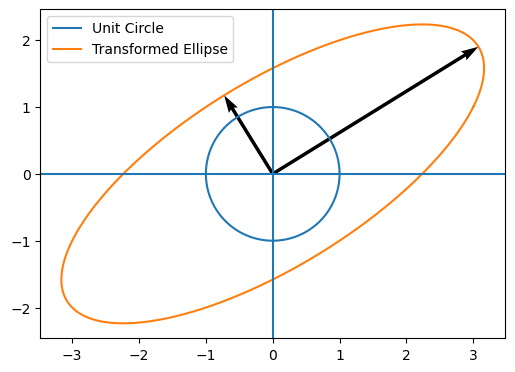

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define matrix
A = np.array([[3, 1],
              [1, 2]])

# Generate unit circle
t = np.linspace(0, 2*np.pi, 400)
circle = np.vstack((np.cos(t), np.sin(t)))

# Transform circle
ellipse = A @ circle

# Compute eigenvalues & eigenvectors
eigvals, eigvecs = np.linalg.eig(A)

# Plot
plt.figure(figsize=(6,6))

# Original circle
plt.plot(circle[0], circle[1], label="Unit Circle")

# Transformed ellipse
plt.plot(ellipse[0], ellipse[1], label="Transformed Ellipse")

# Plot eigenvectors
for i in range(2):
    vec = eigvecs[:, i]
    plt.quiver(0, 0,
               vec[0]*eigvals[i],
               vec[1]*eigvals[i],
               angles='xy',
               scale_units='xy',
               scale=1)

plt.axhline(0)
plt.axvline(0)
plt.gca().set_aspect('equal')
plt.legend()
plt.show()

## Statistical Connections: Covariance and Principal Component Analysis (PCA)

The mathematical machinery of eigenvalues scales seamlessly from the geometric transformations of 2D visualistion plane to the rigorous statistical analysis of immense, high-dimensional datasets. Principal Component Analysis (PCA) stands as the premier algorithm for linear dimensionality reduction and feature extraction covariance matrices.

### The Geometry of the Empirical Covariance Matrix 

Given a throughly mean-centered dataset represented by the matrix, $X \in \mathbb{R}^{n \times p}$, containing samples and $p$ variable features, the empirical covariance matrix is mathematically calculated as $\Sigma = \frac {1}{n-1}X^T X$. This resulting covariance matrix is a $p \times p$ square matrix that perfectly encapsulates the pairwise statistical correlations between all possible dimensions in the dataset.<br>
By strict mathematical definition, the product $X^T X$ produces a symmetric positive semi-definite matrix. Because the covariance matrix is perfectly symmetric across its diagonal, the foundational laws of the Spectral Theorem immediately apply: the covariance matrix is mathematically guaranteed to possess strictly real, non-negative eigenvalues and a complete set of mutually orthogonal eigenvectors.<br>
In the original feature coordinate space, variables are frequently correlated with one another, meaning the covariance matrix contains significant non-zero off-diagonal elements. The fundamental goal of the PCA algorithm is to discover a completely new geometric basis - a rotated coordinate system - where the projected data exhibits absolutedly zero linear correlation between distinct axes. In this newly discovered space, the empirical covariance matrix must be purely diagonal. The geometric transformation matrix that flawlessly accoomplishes this decorrelation is the orthogonal matrix $Q$, which is constructed directly by concatenating the eigenvectors of the original covariance matrix. 

### The Rayleigh Quotient and the Maximisation of Variance

To deeply understand exactly why the eigenvectors of the covariance matrix yield the mathematically optimal projection axes for PCA, one must evaluate the formal quadratic definition of statistical variance. For a centered data matrix $X$, the statistical variance of the dataset projected onto any arbitrary unit vector $v$ (where the lenght $||v|| = 1$) is given by the algebraic quadratic form:
$$var(Xv) = v^T \Sigma v$$
The primary optimisation objective of Principla Component Analysis is to search the high-dimensional space to identify the exact projection direction $v_1$ that explictly maximises this variance. This continuous optimisation problem is strictly bounded by the geometric constraint that the projection vector $v$ must be a unit vector ($v^T v = 1$). This constrained optimisation maps perfectly onto a renowned mathematical construct known as the Rayleign quotient, denoted as $R(v)$ : 
$$R(v) = \frac {v^T \Sigma v}{v^T v}$$
For any valid unit vector, the denominator of this fraction is exactly 1, meaning the actual variance in that direction is precisely equal to the Rayleigh quotient. A standard theorem of positive semi-definite symmetric matrices (often referred to mathematically as the Min-Max Theorem or Theorem 5.1 in advanced literature) provides the rigorous variational characterisation of eigenvalues. This theorem states definitively that the maximum possible value of the Rayleigh quotient ($R(v)$) over the entire vector space is exactly equal to the largest eigenvalue $\lambda_1$ of the matrix, and critically, this theoretical maximum is achieved if and only if the projectoin vector $v$ is perfectly aligned with the corresponding eigenvector $v_1$. <br>
The mathematical proof of this characterisation relies on decomposing the covariance matrix $\Sigma = V \Lambda V^T$ and substituting a new vector parameter $w = V^T v$. Through this substitution, the Rayleigh quotient transforms elegantly into a weighted convex combination of the matrix's eigenvalues : $\frac{\sum w_i^2 \lambda_i}{\sum w_i^2}$. Because eigenvalues are ordered by magnitude such that $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_p$, the mathematical upper bound of this weighted sum strictly occurs when 100% of the statistical weight is placed exclusively on the largest eigenvalue $\lambda_1$. This occurs geometrically when $w$ is the first standard basis vector, which algebraically forces $v = v_1$. <br>
Therefore, the first principal component - formally defined as the spatial direction capturing the absolute maximum amount of variance within the dataset - is mathematically mandated to be the exact eigenvector corresponding to the largest eigenvalue of the empirical covariance matrix. 

### Eigenvalues as the Metric of Explained Variance 

Once the first principal component is identified, the remaining data variance is projected onto the remaining orthogonal subspaces, sequentially finding the subsequent eigenvectors associated with $\lambda_2, \lambda_3$, and so forth in descending order. A beutiful statistical symmetry emerges here: the sum of all the individual variances along the original feature axes (the trace of the covariance matrix) is strictly equal to the sum of all the eigenvalues of the covariance matrix.<br>
This exact equivalence establishes a direct, highly interpretable statistical meaning for eigenvalues. The specific numerical value of the eigenvalue $\lambda_k$ represents the exact absolute magnitude of variance explained by projecting the data onto the $k-th$ principal component (eigenvector). Consequently, the proportion of total variance encapsulated by any specific eigenvector is trivially calculated as a simple ration: 
$$\text{Explained Variance Ratio} = \frac{\lambda_k}{\sum_{i=1}^{p} \lambda_i}$$
By computing the eigenvalues, a data scientist can rank the orthogonal eigenvectors in descending order of informational value. Directions in space associated with negligible or near-zero eigenvalues indicate geometric dimensions where the dataset is fundamentally flat, containing virtually no meaningful variance or statistical information. By intentionally discarding the eigenvectors associated with these vanishing small eigenvalues, practitioners achieve massive dimensionality reduction while mathematically minimisng the mean-squared reconstruction error of the entire dataset. In PCA, the geometric stretching factor from theoretical linear algebra is transformed effortlessly into a direct metric of statistical information density.

## Deep Learning Dynamics: Exploding Gradients and the Spectral Radius 

While eigenvalues represent the static geometric axes of maximum variance in Principal Component Analysis, they represent dynamic, highly volatile chaos in the realm of deep learning. The training of complex artificial neural networks, specifically highly deep feedforward architectures and Recurrent Neural Networks (RNNs) , relies entirely on the backpropagation algorithm to iteratively optimise massive weight matrices. The mathematical stability of this continuous backpropgation process is almost entirely governed by the spectral radius of the network's weight matrices and layer-to-layer Jacobians, providing a profound bridge between pure linear algebra and the notorious exploding and vanishing gradient problems.

### The Chain Rule and the Backpropagated Jacobian Matrix

During the standard neural network traking loop, the network executes a forward pass to generate predictions, computes an aggregate error via a loss function, and propagates these error signals backward through the computational graph to update the individual model parameters. This backward propagation process is fundamentally a massive application of the multivariable chain rule of calculus. <br>
In a standard recurrent neural network operating over sequential data, a continuous hidden state $h_t$ at time step $t$ is computed dynamically from the previous hidden state $h_t$ using a shared recurrent weight matrix $W$, an input sequence $x_t$, and a nonlinear activation function $\sigma$:
$$h_t = \sigma(W h_{t-1} + U x_t)$$
To update the shared weights successfully, the network must compute the precise gradient of the final loss calculated at time step $T$ with respect to the earliest hidden states (e.g., $h_1$). This requires computing the continuous partial derivative $\frac{\partial h_T}{\partial h_1}$. Due to the sequential , unrolled nature of the RNN architectur, this final derivative is the compounding mathematical product of local Jacobian matrices $J_t$ across all individual time steps from 1 to $T$:
$$\frac{\partial h_T}{\partial h_1} = \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}} = \prod_{t=1}^{T} \text{diag}(\sigma'(z_t)) W^T$$
In the rigorous mathematical formulation, the term $\text{diag}(\sigma'(z_t))$ represents a diagonal matrix containing the local derivative of the non-linear activation function, and $W^T$ is the transpose of the shared recurrent weight matrix. Because the backward pass calculates gradients through purely linear matrix multiplications - completely independent of the forward pass's non-linear squashing operations - the overall gradient dynamics are overwhelming dominated by the repeated, sequential exponentiation of the matrix $W^T$. 

### The Spectral Radius and Gradient Instability 

The mathematical behaviour of any matrix raised to a very large power $T$ is fundamentally and inescapably dictated by its eigenvalues. The spectral radius of a given matrix, mathematically denoted as $\rho(W)$, is formally defined as the absolute maximum value among all of its eigenvalues: $\rho(W) = \max |\lambda_i|$. The spectral radius acts as the strict upper bound on how much the matrix can scale any vector space during a transformation. <br>
In a simplified linear network approximation (where the activation function is linear, meaning its derivative $\sigma'$ is bounded to exactly 1), the backpropagated error gradient is directly proportional to the matrix exponentiation $(W^T)^{T-1}$. The long-term behaviour of this exponential product bifurcates catastrophically based on the exact numerical value of the spectral radius : 
- **Exploding Gradients** ($\rho(W) > 1$): If the absolute largest eigenvalue of the shared weight matrix is strictly greater than 1, the repeated multiplication during backpropagation acts exactly like exponential compound interest. The gradient vectors grow exponentially in magnitude with every step of network depth or sequence length. Eventually, this compounding growth causes the numerical parameter updates to overflow standard floating-point memory limits, resulting in massive systemic instability, NaN (not a Number) values in the loss function, and a complete overshoot the optimal valleys in the multi-dimensional loss landscape, reversing all previous descent progress.
- **Vanishing Gradients** ($\rho(W) < 1$): Conversely, if the absolute largest eigenvalues of the weight matrix is even slightly less than 1, the repeated matrix multiplication causes the backpropagated gradients to decay exponentially toward zero. As the error signal is multiplied by fractions repeatedly, the earlier layers of the network receive effectively no error signal at all. These early layers cease to update their weights and entirely stop learning, preventing the neural network model from capturing any long-term temporal dependencies or semantic structures in the data.
<br>
Nonlinear activation functions further complicate and modulate this spectral dynamic. Unbounded activation functions like Rectified Linear Unit(ReLU) completely lack an upper bound on their positive side and have a constant derivative of exactly 1 for positive inputs. This means they do not biologically attenuate positive error signals. If the weight matrix exhibits an eigenvalue > 1 , the raw inputs and corresponding gradients scale up infinitely without any mathematical limitation, massively accelerating the gradient explosion phenomenon. Conversely, strictly bounded activations like the Sigmoid functions squash values and possess a maximum derivative of 0.25. While this prevents explosive growth, it naturally multiplies the Jacobian by fractions, pushing the entire system heavily toward catastrophic vanishing gradients unless the spectral radius is extraordinary carefully managed through targeted initialisation.
## Spectral Radius and Gradient Stability

| Model Spectral Radius ($\rho(W)$) | Jacobian Norm Effect | Empirical Deep Learning Outcome | Architectural / Algorithmic Mitigation |
|-----------------------------------|----------------------|----------------------------------|-----------------------------------------|
| $\rho(W) < 1$ | Exponential Shrinking | Vanishing Gradients, Failure to learn long sequences | Residual Connections, LSTM Gates, Leaky Units |
| $\rho(W) > 1$ | Exponential Growth | Exploding Gradients, NaN Loss, Optimizer Overshoot | Gradient Clipping, Spectral Normalization |
| $\rho(W) \approx 1$ | Maintained Mathematical Stability | Smooth Convergence, Preserved Error Signals | Orthogonal Matrix Initialization, Unitary RNNs |

## Architectural Mitigations : Spectral Normalisation and Orthogonal Initialisation

The industry recognition that the exploding gradient problem is fundamentally an eigenvalue problem rather than a generic tuning issue has driven the evolution of several mathematically rigorous modern neural network architectures and training methodologies.<br>
Early, highly pragmatic interventions relied heavily on gradient clipping, which involves establishing a strict numerical threshold for the backpropagated vector. If the calculated $L_2$ norm of an error gradient exceeds this arbitrary threshold, the entire vector is scaled down proportionately before the parameter update is applied. While this method is empirical highly effective at preventing terminal numerical overflow and preventing stochastic gradient descent from radically overshoting the minimum, gradient clipping merely treats the symptom rather than curing the underlying spectral disease. Because clipping does not alter the actual matrix parameters, the eigenvalues of the Jacobian remain blown up, meaning the directional flow of the gradient vector may still be highly distorted by the dominant eigenvectors , even if its overall magnitude is artifically suppressed. <br>
To enforce true, structural mathematical stability across deep horizons, training techniques must explicitly control the singular values and eigenvalues of the weight matrices dynamically during the training loop.
1. **Orthogonal Matrix Initialistion**: By purposefully initialising weight matrices as randomly sampled orthogonal matrices rathere than using standard Gaussian distributions, the architecture ensures that all initial eigenvalues have an absolute geometric magnitude of exactly 1.0. This initialisation guarantees that the matrix acts as a pure rigid rotation in high-dimensional space without any initial phases of training, completely preventing immediate vanishing or explosion and allowing the optimiser to find stable initial trajectories.
2. **Spectral Normalisation**: An even more aggressive structural constraint , spectral normalisation mathematically forces the weight matrix to continuously possess a spectral radius less than or equal to 1.0 throughout the entirety of the training process. After every single weight update, the normalisation algorithm computes the largest singular value (which relates directly to the maximum eigenvalue) of the weight matrix. To do this without massive computational overhead, it utilises a highly efficient mathematical approximation known as the power iteration method. Once the largest spectral value is computed, the entire weight matrix is divided by the specific scalar value, This division mathematically guarantees that the matrix satisfies Lipschitz continuity, meaning the transformation matrix is strictly bounded from ever scaling any input feature map or error gradient by a factor greater than 1.0. By rigorously perpetually in check, stabilising highly sensitive architectures keeps gradient explosion perpetually in check, stabilising highly sensitive architectures like Generative Adversarial Networks (GANs) and ultra-deep residual networks.

## Synthesis and Concluding Perspectives

The geometric invarinace of eigenvectors represents a truly remarkable intersection of pure algebraic theory, statistical probabilisticc modelling, and computational algorithmic optimisation. At its absolute foundational base level, solving the characteristic polynomial $\det(A - \lambda I) = 0$ isolates the specific, highly privileged directions in multi-dimensional space that fundamentally resist rotational distortion, revealing the hidden structural axes and the true geometric nature of a linear transformations.<br>
When mathematical symmetry is introduced to the transformation matrix - ensuring strictly real eigenvalues and perfectly orthogonal eigenvectors - the abstract mathematics scale beutifully into the empirical domain of real-world data. By proving mathematically that the maximum of a constrained Rayleign quotient corresponds precisely to the dominant eigenvalue, spectral theory rigorously demonstrates that the eigenvectors of an empirical covariance matrix geometrically embody the exact orthogonal axes of maximum statistical variance. Through this mathematical translation, Principal Component Analysis ceases to be an abstract matrix factorisation and becomes a literal geometric alignment of coordinate systems to the dataset's innate directions of greatest informational stretch.
<br>
Simultaneously, the absolute numerical magnitude of these stretching factors defines the strict mathematical limits of computational stability in artificial intelligence. The training of highly parametrised deep learning models relies on an incredibly delicate balance of sequential Jacobian multiplication operating across hundreds of layers or time steps. If the spectral radius of the parameter weight matrices strays significantly above the strict threshold of 1.0, the underlying geometry of the computational space undergoes violent, uncontrollable compound expansion. This geometric explosion blows up the backward flow of error gradients, causing numerical overflow and completely obliterating the model's learning trajectory.<br>
Ultimately, whether tracing the manual analytical calculation of a simple two-dimensional array, decomposing the statistical variance of a massive dataset via empirical covariance matrices, or constraining the volatile insight remains beutifully unchanged: truly understanding how any complex system operates upon its environment requires precisely identifying the specific geometric axes that remain invariant, and measuing exactly how forcefully the system scales them.